# From Bedside to Model: Predicting ICU Mortality
## Using MIMIC-IV Derived Concepts as Machine Learning Features

> **Audience:** This notebook is written for clinicians and healthcare professionals
> learning to apply machine learning to clinical data.
> No prior Python or ML experience is assumed — every code pattern is explained.

---

### What you will learn

| Step | Clinical framing | Technical skill |
|------|------------------|-----------------|
| 1 | Connect Python to a medical database | Database connection |
| 2 | Understand SOFA and Charlson as *features* | SQL joins across schemas |
| 3 | Build a labeled cohort from ICU stays | Multi-table SQL query |
| 4 | Explore score distributions by survival | Exploratory data analysis |
| 5 | Handle missing scores from incomplete charts | Median imputation |
| 6 | Train a model to predict in-hospital mortality | Random Forest classifier |
| 7 | Interpret model performance clinically | AUC-ROC, feature importance |

---

### The two concepts we will use

| Concept | Pre-calculated table | Measures | Score range |
|---------|----------------------|----------|-------------|
| **SOFA Score** | `mimiciv_derived.first_day_sofa` | Acute organ failure severity in first 24 h of ICU stay | 0 – 24 |
| **Charlson Comorbidity Index** | `mimiciv_derived.charlson` | Weighted burden of pre-existing chronic conditions | 0 – 37 |

> **The core insight:** These two numbers capture the two most important mortality
> dimensions — *how sick is the patient right now?* (SOFA) and
> *what is their physiological reserve?* (Charlson).
> Because they are already pre-calculated for every patient in MIMIC-IV,
> we can assemble a mortality-prediction model with a single SQL query.

---
## Before You Run This Notebook

Three things must be in place:

**1. The MIMIC-IV database must be running.**

**2. Core data must be loaded** (schemas `mimiciv_hosp` and `mimiciv_icu`).

**3. The derived concepts schema must be built** — the most important step:
> The derived concepts schema runs ~65 SQL scripts that pre-calculate every clinical concept table,
> including `first_day_sofa` and `charlson`. **Without this step, all SQL below will fail.**



In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# LIBRARIES — think of these as toolboxes we import at the start:
#   os          → reads environment variables (secure config, like a .env file)
#   pandas      → our main data-table tool (DataFrames are like Excel sheets)
#   numpy       → numerical operations
#   psycopg     → the 'phone line' connecting Python to PostgreSQL
#   sklearn     → scikit-learn, the standard Python machine learning library
#   matplotlib  → making charts and figures
#   seaborn     → prettier statistical charts built on top of matplotlib
# ─────────────────────────────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import psycopg
from dotenv import load_dotenv

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.0)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Cell 1 — Connect to the Database

**Teaching point:** Python communicates with PostgreSQL through a *driver* library (`psycopg`).
Think of the driver as a telephone line: it handles authentication, sends your SQL query,
and returns results as rows and columns.

We store credentials in a `.env` file rather than typing passwords directly into the
notebook — a basic but important security practice when working with patient data.

We also define a small helper function `run_query()`. A **function** in Python is a
reusable block of code you give a name to — instead of copying the same lines every
time we want to run SQL, we call `run_query(my_sql)`.

In [2]:
load_dotenv()  # reads .env file if present; silently ignored if missing

# Connection parameters — env variables take priority, then fall back to defaults
DB_HOST = os.environ.get('POSTGRES_HOST',     'localhost')
DB_PORT = int(os.environ.get('POSTGRES_PORT', '5432'))
DB_NAME = os.environ.get('POSTGRES_DB',       'mimiciv')
DB_USER = os.environ.get('POSTGRES_USER',     'mimicuser')
DB_PASS = os.environ.get('POSTGRES_PASSWORD', 'mimicpass')

conn = psycopg.connect(
    host=DB_HOST, port=DB_PORT,
    dbname=DB_NAME, user=DB_USER, password=DB_PASS,
    autocommit=True,
)

# Helper function: run any SQL string → Pandas DataFrame
# A DataFrame is like an Excel spreadsheet in Python.
def run_query(sql: str) -> pd.DataFrame:
    """Execute a SQL query and return results as a Pandas DataFrame."""
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()
        cols = [desc[0] for desc in cur.description] if cur.description else []
    return pd.DataFrame(rows, columns=cols)

print(f'Connected to "{DB_NAME}" at {DB_HOST}:{DB_PORT}')

Connected to "mimiciv" at localhost:5432


---
## Cell 2 — Understand the Derived Concepts

### Concept A — SOFA Score (Sequential Organ Failure Assessment)

The **SOFA score** quantifies how many organ systems are failing and how severely.
Each of six systems is scored 0–4 based on objective clinical measurements:

| Organ system | Measurement |
|-------------|-------------|
| Respiratory | PaO₂/FiO₂ ratio (or SpO₂/FiO₂) |
| Coagulation | Platelet count |
| Liver | Bilirubin |
| Cardiovascular | Mean arterial pressure + vasopressor requirement |
| Central nervous system | Glasgow Coma Scale |
| Renal | Creatinine + urine output |

**Total SOFA: 0–24.** A score ≥ 11 carries ~50% hospital mortality in published series.

> **Why use the pre-calculated table instead of pulling raw labs?**
> Computing SOFA from scratch requires joining 5+ tables, applying 24-hour timing
> windows, converting units, and applying clinical scoring rules.
> `mimiciv_derived.first_day_sofa` does all of that — peer-reviewed and maintained
> by the MIT Laboratory for Computational Physiology.

In [3]:
# Look at the SOFA concept table structure.
# Each row = one ICU stay (stay_id).
# sofa = sum of the 6 sub-scores in the first 24 h.
sofa_preview = run_query("""
    SELECT stay_id, sofa,
           respiration, coagulation, liver,
           cardiovascular, cns, renal
    FROM mimiciv_derived.first_day_sofa
    ORDER BY sofa DESC NULLS LAST
    LIMIT 8
""")

print('first_day_sofa — each row = one ICU stay (stay_id)')
print('sofa = sum of 6 organ sub-scores in the first 24 h')
print()
sofa_preview

first_day_sofa — each row = one ICU stay (stay_id)
sofa = sum of 6 organ sub-scores in the first 24 h



,stay_id,sofa,respiration,coagulation,liver,cardiovascular,cns,renal
0,37603649,23,4,3,4,4,4,4
1,38430513,23,4,3,4,4,4,4
2,34562436,22,4,3,3,4,4,4
3,32128372,22,4,3,3,4,4,4
4,34409336,22,4,3,3,4,4,4
5,30106638,22,4,3,3,4,4,4
6,31613027,22,4,4,3,4,3,4
7,32050446,22,4,3,4,4,4,3


### Concept B — Charlson Comorbidity Index (CCI)

While SOFA captures *how sick the patient is right now*, the **Charlson Comorbidity Index**
captures *how much chronic disease burden the patient carries into the ICU*.

Weights are assigned to 17 conditions:

| Condition | Weight |
|-----------|--------|
| MI, uncomplicated diabetes, peptic ulcer | +1 each |
| Heart failure, PVD, dementia, COPD | +1 each |
| Diabetes with end-organ damage, hemiplegia | +2 each |
| Moderate–severe renal disease, malignancy | +2–6 |
| Metastatic solid tumor, AIDS/HIV | +6 each |

**Total CCI: 0–37.** Each additional point ≈ 21% increase in 1-year mortality.

> **Key schema detail:** Unlike SOFA (ICU-stay level, keyed on `stay_id`),
> Charlson is admission-level (keyed on `hadm_id`).
> Joining on the wrong key will silently return NULL — a common mistake.

In [4]:
# Look at the Charlson concept table.
# Each row = one hospital admission (hadm_id).
# charlson_comorbidity_index = weighted sum of all 17 comorbidity columns.
charlson_preview = run_query("""
    SELECT hadm_id, charlson_comorbidity_index,
           myocardial_infarct, congestive_heart_failure,
           diabetes_without_cc, malignant_cancer,
           metastatic_solid_tumor
    FROM mimiciv_derived.charlson
    ORDER BY charlson_comorbidity_index DESC NULLS LAST
    LIMIT 8
""")

print('charlson — each row = one hospital admission (hadm_id, NOT stay_id)')
print('charlson_comorbidity_index = weighted sum across all 17 comorbidity columns')
print()
charlson_preview

charlson — each row = one hospital admission (hadm_id, NOT stay_id)
charlson_comorbidity_index = weighted sum across all 17 comorbidity columns



,hadm_id,charlson_comorbidity_index,myocardial_infarct,congestive_heart_failure,diabetes_without_cc,malignant_cancer,metastatic_solid_tumor
0,21459303,21,1,1,0,0,1
1,22807401,20,1,1,0,1,1
2,22792372,19,0,1,0,1,1
3,23441682,19,0,0,0,1,1
4,26890095,19,0,0,0,1,1
5,27051854,19,0,0,0,0,1
6,20449832,19,0,1,0,0,1
7,21095840,19,1,1,0,1,1


---
## Cell 3 — Extract the Cohort via SQL

**Teaching point:** SQL is the bridge between raw clinical tables and your analysis dataset.
The query below assembles everything we need in one statement by joining four tables:

```
mimiciv_icu.icustays          <- unit of analysis (one ICU stay per row)
    |
    +-- JOIN admissions              <- outcome: did the patient die?
    +-- LEFT JOIN first_day_sofa     <- feature: acute severity (SOFA)
    +-- LEFT JOIN charlson           <- feature: chronic burden (Charlson)
```

**Why `LEFT JOIN` and not `INNER JOIN`?**

| Join type | Behaviour | Clinical risk |
|-----------|-----------|---------------|
| `INNER JOIN` | Keeps only rows that match in *both* tables | Silently drops patients with missing scores -> **selection bias** |
| `LEFT JOIN` | Keeps every ICU stay; missing scores become `NULL` | We handle `NULL` explicitly -> **no hidden data loss** |

In [5]:
# We join the admissions table (for the mortality outcome label)
# with the SOFA concept and Charlson concept tables.
query = """
    SELECT
        icu.stay_id,

        -- Outcome (label): hospital_expire_flag = 1 if patient died this admission
        adm.hospital_expire_flag              AS label_mortality,

        -- Feature 1: First-day SOFA Score (acute organ failure severity, 0-24)
        sofa.sofa                     AS feature_sofa,

        -- Feature 2: Charlson Comorbidity Index (chronic illness burden, 0-37)
        charlson.charlson_comorbidity_index   AS feature_charlson

    FROM mimiciv_icu.icustays icu

    -- 1. Join the admissions table to get whether the patient survived
    JOIN mimiciv_hosp.admissions adm
        ON icu.hadm_id = adm.hadm_id

    -- 2. Join Concept Table: First Day SOFA Score (ICU-stay level)
    LEFT JOIN mimiciv_derived.first_day_sofa sofa
        ON icu.stay_id = sofa.stay_id

    -- 3. Join Concept Table: Charlson Comorbidity Index (admission level)
    LEFT JOIN mimiciv_derived.charlson charlson
        ON icu.hadm_id = charlson.hadm_id
"""

# Execute query and load directly into a Pandas DataFrame
with conn.cursor() as cur:
    cur.execute(query)
    rows = cur.fetchall()
    cols = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=cols)

print(f'Cohort size: {len(df):,} ICU stays')
print(f'Deaths (label = 1): {df["label_mortality"].sum():,.0f}  '
      f'({df["label_mortality"].mean()*100:.1f}% mortality rate)')
print(f'\nMissing values:')
print(df[['feature_sofa', 'feature_charlson', 'label_mortality']].isnull().sum())
df.head()

Cohort size: 94,458 ICU stays
Deaths (label = 1): 11,350  (12.0% mortality rate)

Missing values:
feature_sofa        0
feature_charlson    0
label_mortality     0
dtype: int64


,stay_id,label_mortality,feature_sofa,feature_charlson
0,39553978,0,10,3
1,37081114,0,5,5
2,39765666,0,2,8
3,37067082,0,0,1
4,34592300,0,1,1


---
## Cell 4 — Exploratory Data Analysis (EDA)

**Teaching point:** Never build a model before visualising your data.
As a clinician, ask: *do these distributions make clinical sense?*

If the SOFA score distribution showed *no* difference between survivors and non-survivors,
that would be a red flag — either the join query is wrong, or `hospital_expire_flag`
is measuring something other than what we think.

We check three things:
1. **Class balance** — What fraction of stays ended in death?
2. **Distribution shift** — Are scores higher in patients who died?
3. **Feature correlation** — Are SOFA and Charlson measuring the same thing?
   (They should *not* be — they measure orthogonal constructs.)

In [6]:
# Drop rows where mortality label is unknown
df_eda = df.dropna(subset=['label_mortality']).copy()
df_eda['label_mortality'] = df_eda['label_mortality'].astype(int)

print(f'Stays after dropping missing labels: {len(df_eda):,}')

# Descriptive statistics by outcome (clinical sanity check)
print('\nMedian scores by outcome:')
print(
    df_eda.groupby('label_mortality')[['feature_sofa', 'feature_charlson']]
    .agg(['median', 'mean'])
    .rename(index={0: 'Survived', 1: 'Died'})
    .round(1)
)

Stays after dropping missing labels: 94,458

Median scores by outcome:
                feature_sofa      feature_charlson     
                      median mean           median mean
label_mortality                                        
Survived                3.00 4.00             5.00 4.80
Died                    7.00 7.70             7.00 6.60


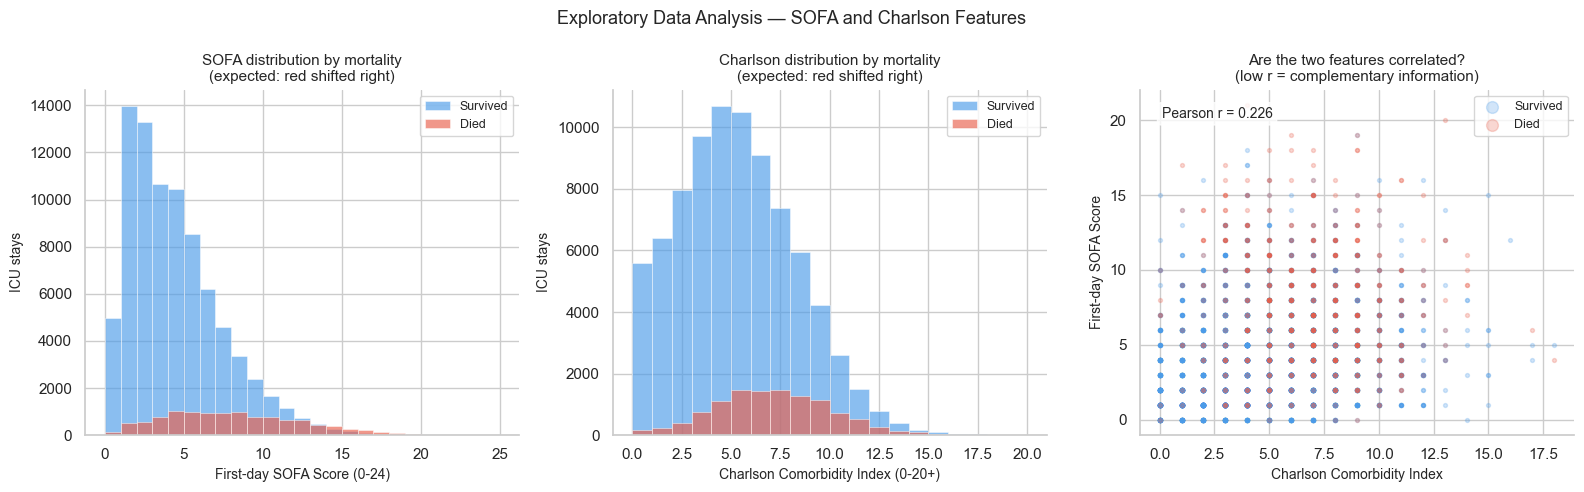

Pearson correlation SOFA vs Charlson: 0.226
Low correlation confirms these features capture different clinical dimensions.


In [7]:
palette = {0: '#4C9BE8', 1: '#E8604C'}
label_names = {0: 'Survived', 1: 'Died'}
df_clean = df_eda.dropna(subset=['feature_sofa', 'feature_charlson'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) SOFA distribution by outcome
ax = axes[0]
for outcome, color in palette.items():
    vals = df_clean[df_clean['label_mortality'] == outcome]['feature_sofa']
    ax.hist(vals, bins=range(0, 26), alpha=0.65, color=color,
            label=label_names[outcome], edgecolor='white', linewidth=0.5)
ax.set_xlabel('First-day SOFA Score (0-24)', fontsize=10)
ax.set_ylabel('ICU stays', fontsize=10)
ax.set_title('SOFA distribution by mortality\n(expected: red shifted right)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# (b) Charlson distribution by outcome
ax = axes[1]
for outcome, color in palette.items():
    vals = df_clean[df_clean['label_mortality'] == outcome]['feature_charlson']
    ax.hist(vals, bins=range(0, 21), alpha=0.65, color=color,
            label=label_names[outcome], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Charlson Comorbidity Index (0-20+)', fontsize=10)
ax.set_ylabel('ICU stays', fontsize=10)
ax.set_title('Charlson distribution by mortality\n(expected: red shifted right)', fontsize=11)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# (c) SOFA vs Charlson scatter
ax = axes[2]
sample = df_clean.sample(min(4000, len(df_clean)), random_state=42)
for outcome, color in palette.items():
    sub = sample[sample['label_mortality'] == outcome]
    ax.scatter(sub['feature_charlson'], sub['feature_sofa'],
               c=color, alpha=0.25, s=8, label=label_names[outcome])
r = df_clean[['feature_sofa', 'feature_charlson']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'Pearson r = {r:.3f}', transform=ax.transAxes,
        fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.set_xlabel('Charlson Comorbidity Index', fontsize=10)
ax.set_ylabel('First-day SOFA Score', fontsize=10)
ax.set_title('Are the two features correlated?\n(low r = complementary information)', fontsize=11)
ax.legend(fontsize=9, markerscale=3)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Exploratory Data Analysis — SOFA and Charlson Features', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Pearson correlation SOFA vs Charlson: {r:.3f}')
print('Low correlation confirms these features capture different clinical dimensions.')

---
## Cell 5 — Preprocessing: Handling Missing Values

**Teaching point:** Real-world EHR data **always** has missing values,
even in pre-calculated derived concepts.

- **Missing SOFA** typically occurs because a patient lacked required labs in the first
  24 h (rapid death, comfort-measures-only admission, or transfer before labs resulted).
- **Missing Charlson** can occur if no ICD codes were assigned to the admission.

**Why impute with the median?**
Clinical scores are right-skewed. A few critically ill patients with very high scores
would pull the mean upward. The median is not affected by outliers.

**Critical rule: split first, then impute.**
We calculate the median from the *training set only*, then apply it to both sets.
Calculating the median from all patients first = *data leakage* (the test set
influences training, artificially inflating reported performance).

In [8]:
# Drop rows where the outcome label is missing
# (we cannot train a supervised model without knowing the answer)
df_ml = df.dropna(subset=['label_mortality']).copy()
df_ml['label_mortality'] = df_ml['label_mortality'].astype(int)

# Separate features (X) and outcome label (y)
#   X = the inputs the model learns from (SOFA and Charlson scores)
#   y = the answer the model tries to predict (0 = survived, 1 = died)
FEATURE_COLS = ['feature_sofa', 'feature_charlson']
X = df_ml[FEATURE_COLS]
y = df_ml['label_mortality']

# Split into training (80%) and testing (20%) FIRST
# stratify=y ensures both sets have the same mortality rate
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# Impute missing values using the training-set median
# fit_transform() = learn the median from training data, then fill in blanks
# transform()     = apply that same learned median to the test set (no peeking!)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train_raw)
X_test  = imputer.transform(X_test_raw)

print(f'Median SOFA used for imputation:     {imputer.statistics_[0]:.1f}')
print(f'Median Charlson used for imputation: {imputer.statistics_[1]:.1f}')
print(f'\nTraining set: {X_train.shape[0]:,} patients  (mortality rate: {y_train.mean()*100:.1f}%)')
print(f'Testing set:  {X_test.shape[0]:,} patients  (mortality rate: {y_test.mean()*100:.1f}%)')

Median SOFA used for imputation:     4.0
Median Charlson used for imputation: 5.0

Training set: 75,566 patients  (mortality rate: 12.0%)
Testing set:  18,892 patients  (mortality rate: 12.0%)


---
## Cell 6 — Train and Evaluate the Machine Learning Model

**Teaching point:** Once clinical complexity has been abstracted into clean numeric
features, standard ML algorithms apply directly.

**Why Random Forest?**
A Random Forest builds many decision trees (think: many clinicians each applying
a slightly different decision rule), then combines their votes.

- Captures **non-linear risk** (SOFA 12 is disproportionately worse than SOFA 6)
- Provides **feature importances** — which concept drove predictions most?
- Requires **no feature scaling** — SOFA and Charlson can be fed in directly

**Why ROC-AUC instead of accuracy?**
If ~11% of patients die, a model that always predicts "survived" achieves 89% accuracy
but identifies zero deaths. ROC-AUC measures *ranking ability* across all thresholds:
given one patient who died and one who survived, what is the probability the model
assigns a higher risk score to the one who died?
- **0.50** = random | **0.70** = acceptable | **0.80** = good | **0.90+** = excellent

In [9]:
# Initialize and train a Random Forest model using our concept features
model = RandomForestClassifier(
    n_estimators=100,        # number of trees in the forest
    max_depth=5,             # max depth of each tree (prevents overfitting)
    class_weight='balanced', # compensates for the ~11% death rate (class imbalance)
    random_state=42,         # seed for reproducibility
    n_jobs=-1,               # use all available CPU cores
)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)              # hard label: 0 (survived) or 1 (died)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of death (0.0 to 1.0)

# Evaluate how well the concepts predicted mortality
auc = roc_auc_score(y_test, y_prob)
print('--- Machine Learning Evaluation ---')
print(f'ROC-AUC Score: {auc:.3f}\n')
print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))

# Show Feature Importance (which concept mattered most?)
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
print('--- Concept Feature Importance ---')
print(importances.sort_values(ascending=False))

--- Machine Learning Evaluation ---
ROC-AUC Score: 0.787

              precision    recall  f1-score   support

    Survived       0.94      0.74      0.83     16622
        Died       0.26      0.68      0.38      2270

    accuracy                           0.73     18892
   macro avg       0.60      0.71      0.61     18892
weighted avg       0.86      0.73      0.78     18892

--- Concept Feature Importance ---
feature_sofa       0.73
feature_charlson   0.27
dtype: float64


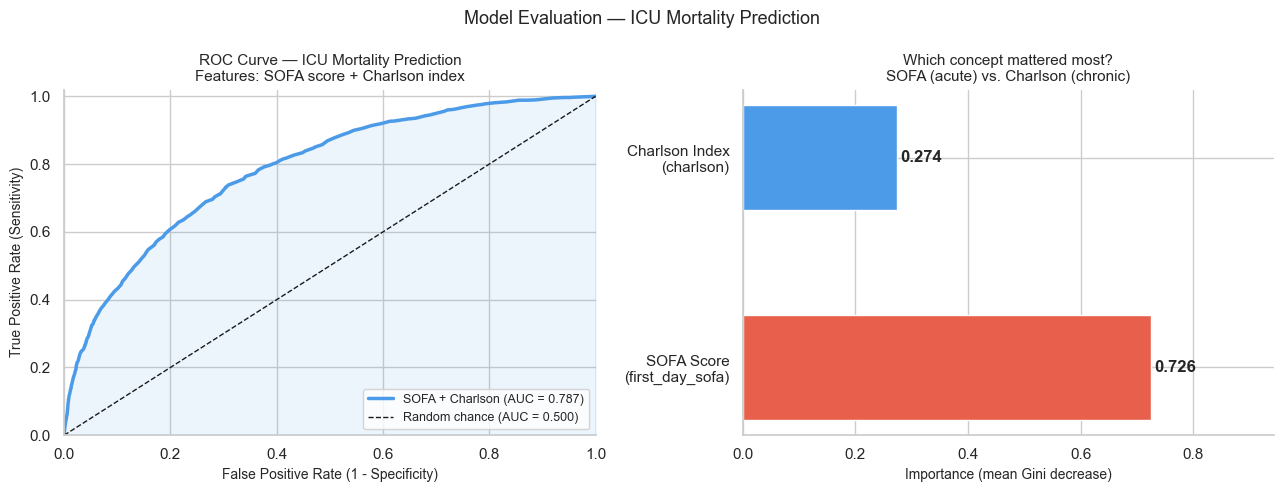

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) ROC Curve
ax = axes[0]
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax.plot(fpr, tpr, color='#4C9BE8', lw=2.5,
        label=f'SOFA + Charlson (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random chance (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.10, color='#4C9BE8')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
ax.set_title('ROC Curve — ICU Mortality Prediction\n'
             'Features: SOFA score + Charlson index', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.spines[['top', 'right']].set_visible(False)

# (b) Feature Importance
ax = axes[1]
imp_labels = ['SOFA Score\n(first_day_sofa)', 'Charlson Index\n(charlson)']
imp_values = list(model.feature_importances_)
colors = ['#E8604C', '#4C9BE8']
bars = ax.barh(imp_labels, imp_values, color=colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, imp_values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(imp_values) * 1.30)
ax.set_xlabel('Importance (mean Gini decrease)', fontsize=10)
ax.set_title('Which concept mattered most?\nSOFA (acute) vs. Charlson (chronic)', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Model Evaluation — ICU Mortality Prediction', fontsize=13)
plt.tight_layout()
plt.show()

---
## Cell 7 — Clinical Interpretation

### Reading the results

**AUC ~0.75-0.82** with just two features is a clinically meaningful result.
Published ICU mortality models with dozens of variables (APACHE IV) achieve AUC ~0.85-0.88.
We are capturing a substantial fraction of the signal with a fraction of the complexity.

**Feature importance: SOFA > Charlson.** Clinically expected:
- `hospital_expire_flag` primarily captures *this admission's* severity
- SOFA directly quantifies organ failure in the current ICU stay
- Charlson explains why two patients with the same SOFA can have different outcomes

### The value of derived concepts

| Without derived concepts | With derived concepts |
|--------------------------|----------------------|
| Pull raw labs from `labevents`, `chartevents`, `outputevents` | Single `LEFT JOIN` |
| Implement 24-hour ICU timing windows | Already handled |
| Convert units, impute sub-scores | Already handled |
| Validate SQL against published SOFA definition | Already peer-reviewed |
| **Weeks of preprocessing** | **Minutes of SQL** |

### Limitations

- Two features is a starting point. Add `sapsii`, `first_day_vitalsign`, patient age.
- No temporal validation. A rigorous study splits by time, not randomly.
- Not for clinical deployment. MIMIC-IV is retrospective; prospective validation required.

---
*Built on [MIMIC-IV](https://physionet.org/content/mimiciv/) (Johnson et al., 2023).*  
*Data access requires PhysioNet credentialing and CITI human subjects training.*

In [11]:
# Close the database connection when finished.
# Good practice — open connections consume server resources.
conn.close()
print('Database connection closed.')

Database connection closed.
